## Sign Model — Direction Prediction

This notebook builds a **directional model** that predicts the sign of the next price move, conditional on a move actually occurring.

The sign model is trained only on timestamps where a move occurs, using microstructure features such as LOB imbalance, liquidity, and trade flow.

**Goal:** combine both models into a single trading signal. Only trade when a move is likely, and use the sign model to determine the direction.

In [1]:
import pandas as pd
import numpy as np
from binance.client import Client
import time
import black
from pympler import asizeof
import math
import matplotlib.pyplot as plt
import glob

In [2]:
files_final = glob.glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet")

final_dataset = pd.concat([pd.read_parquet(f) for f in files_final])

In [3]:
final_dataset = final_dataset.sort_values("timestamp").reset_index(drop=True)

final_dataset = final_dataset.dropna().reset_index(drop=True)

final_dataset["mid_price_change_1_sign"] = final_dataset["mid_price_change_1_sign"].replace(-1.0,0.0)

final_dataset["mid_price_moves"].value_counts()

mid_price_moves
0    25213
1    18786
Name: count, dtype: int64

# Base features
- keep the same feature set as Model 1 for the initial version  
- then extend with additional features identified in the EDA notebook (05)

In [4]:
features = [
    # Vol
    "realized_vol_20_log1p",
    "realized_vol_5_log1p",

    # trade intensity
    "trade_count_log1p",
    "trade_count_change",

    # trade size
    "std_trade_size_log1p",
    "max_trade_size_log1p",
    "avg_trade_size_log1p",

    # liquidity
    "total_bid_volume_10_log1p",
    "total_book_volume_log1p",

    # volume_pressure
    "max_bid_ask_vol_ratio_log1p",

    # spread
    "rel_spread_log1p",

    # imbalance
    "imbalance_5",
    "imbalance_10",
    "imbalance_depth_3",

    # depth shape
    "lob_depth_ratio_4",
    "lob_depth_ratio_2",

    # trade_flow
    "sell_volume_log1p",
]


additional =[
    "trade_volume_imbalance",
    "lag_trade_volume_imbalance_1",
    "imbalance_1",
    "lob_depth_ratio_3",
    "lob_depth_ratio_5",
    "mid_minus_micro",
    "microprice_change",
    "log_return_1",
    "log_return_2",
    "log_return_3",
    "log_return_5",
    "imbalance_5"
]
features = list(set(features + additional))

target = "mid_price_change_1_sign"

## Finalised Features 

In [5]:
features = [
    "imbalance_5",
    "imbalance_1",
    "trade_volume_imbalance",
    "mid_minus_micro_log1p",
    "max_bid_ask_vol_ratio_log1p",
    "sell_volume_log1p",
    "lob_depth_ratio_3",
    "realized_vol_20_log1p",
    "log_return_2",
    "total_ask_volume_10_log1p",
    "total_bid_volume_10_log1p",
]


# Models

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [7]:
LINEAR_MODELS = {
    "logreg_l2": LogisticRegression(l1_ratio=0, C=1.0, solver="lbfgs", max_iter=5000),
    "logreg_l2_strong": LogisticRegression(l1_ratio=0, C=0.1, solver="lbfgs", max_iter=5000),
    "logreg_l1": LogisticRegression(l1_ratio=1.0, C=0.1, solver="liblinear", max_iter=5000),
    "logreg_en": LogisticRegression(l1_ratio=0.5, C=0.1, solver="saga", max_iter=5000),
}

TREE_MODELS = {
    "rf": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=50,
        n_jobs=4,
        random_state=42,
        max_features=0.2
    ),

    "xgb": XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=1.0,
    n_jobs=1,
    random_state=42,
    eval_metric="logloss"
),
}

# Again rolling training to somewhat account for regime shift

In [8]:
splits = 10
size_data = len(final_dataset)


tscv = TimeSeriesSplit(n_splits=splits, gap=50, max_train_size=int(size_data/splits))

In [9]:
X = final_dataset[features]
y = final_dataset[target]

# Log reg

In [10]:
import copy

def train_logistic(X, y, model, tscv, clip_quantiles=(0.01, 0.99)):
    n = len(X)
    fold_oof = []
    fold_aucs = []
    coefs = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        oof_preds = np.full(n, np.nan)

        model_fold = model

        X_train = X.iloc[train_idx].copy()
        X_test  = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test  = y.iloc[test_idx].copy()

        train_mask = (final_dataset.iloc[train_idx]["mid_price_moves"] == 1)
        test_mask  = (final_dataset.iloc[test_idx]["mid_price_moves"] == 1)

        X_train = X_train[train_mask]
        y_train = y_train[train_mask]

        X_test = X_test[test_mask]
        y_test = y_test[test_mask]

        lower = X_train.quantile(clip_quantiles[0])
        upper = X_train.quantile(clip_quantiles[1])

        X_train = X_train.clip(lower, upper, axis=1)
        X_test  = X_test.clip(lower, upper, axis=1)

        test_index = X_test.index


        model_fold.fit(X_train, y_train)
        preds = model.predict_proba(X_test)[:, 1]

        oof_preds[test_index] = preds

        auc = roc_auc_score(y_test, preds)
        fold_aucs.append(auc)
        fold_oof.append(oof_preds)
        coefs.append(model_fold.coef_[0])

    results = {
        "fold_oof": fold_oof,
        "fold_aucs": fold_aucs,
        "mean_auc": np.mean(fold_aucs),
        "std_auc": np.std(fold_aucs),
        "min_auc": np.min(fold_aucs),
        "coefs": coefs
    }

    return results

In [11]:
linear_results = {}

for name, model in LINEAR_MODELS.items():

    res = train_logistic(
        X=X,
        y=y,
        model=model,
        tscv=tscv,
    )

    linear_results[name] = res

In [12]:
import pandas as pd

df_linear = pd.DataFrame({
    k: {
        "mean_auc": v["mean_auc"],
        "std_auc": v["std_auc"],
        "min_auc": v["min_auc"],
        "ir": v["mean_auc"] / v["std_auc"]
    }
    for k, v in linear_results.items()
}).T

df_linear.sort_values("ir", ascending=False)

,mean_auc,std_auc,min_auc,ir
logreg_l1,0.845039,0.057527,0.764953,14.689360
logreg_en,0.845643,0.058122,0.765442,14.549328
logreg_l2,0.845963,0.058455,0.766165,14.472038
logreg_l2_strong,0.845758,0.058638,0.764563,14.423287


# tree based

In [13]:
def train_tree(X, y, model, tscv, name, clip_quantiles=(0.01, 0.99)):
    n = len(X)
    fold_oof = []
    fold_aucs = []
    coefs = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        oof_preds = np.full(n, np.nan)

        model_fold = model

        X_train = X.iloc[train_idx].copy()
        X_test  = X.iloc[test_idx].copy()

        y_train = y.iloc[train_idx].copy()
        y_test  = y.iloc[test_idx].copy()

        train_mask = (final_dataset.iloc[train_idx]["mid_price_moves"] == 1)
        test_mask  = (final_dataset.iloc[test_idx]["mid_price_moves"] == 1)

        X_train = X_train[train_mask]
        y_train = y_train[train_mask]

        X_test = X_test[test_mask]
        y_test = y_test[test_mask]

        lower = X_train.quantile(clip_quantiles[0])
        upper = X_train.quantile(clip_quantiles[1])

        X_train = X_train.clip(lower, upper, axis=1)
        X_test  = X_test.clip(lower, upper, axis=1)
        test_index = X_test.index

        model_fold.fit(X_train, y_train)

        preds = model_fold.predict_proba(X_test)[:, 1]

        oof_preds[test_index] = preds

        auc = roc_auc_score(y_test, preds)
        fold_aucs.append(auc)
        fold_oof.append(oof_preds)

        if name == "xgb":
            booster = model.get_booster()
            score = booster.get_score(importance_type="gain")

            imp = pd.Series(score)
            imp = imp.reindex(X.columns, fill_value=0.0)

        else:
            imp = pd.Series(model.feature_importances_, index=X.columns)

        coefs.append(imp)

        #coefs.append(model_fold.feature_importances_)

    imp_df = pd.DataFrame(coefs)

    results = {
        "fold_oof": fold_oof,
        "fold_aucs": fold_aucs,
        "mean_auc": np.mean(fold_aucs),
        "std_auc": np.std(fold_aucs),
        "min_auc": np.min(fold_aucs),
        "coefs": coefs
    }

    return results

In [14]:
tree_results = {}

for name, model in TREE_MODELS.items():

    res = train_tree(
        X=X,
        y=y,
        model=model,
        tscv=tscv,
        name=name,
    )

    tree_results[name] = res

In [15]:
all_results = {
    **linear_results,
    **tree_results
}

In [16]:
import pandas as pd

df_linear = pd.DataFrame({
    k: {
        "mean_auc": v["mean_auc"],
        "std_auc": v["std_auc"],
        "min_auc": v["min_auc"],
        "ir": v["mean_auc"] / v["std_auc"]
    }
    for k, v in all_results.items()
}).T

df_linear.sort_values("ir", ascending=False)

,mean_auc,std_auc,min_auc,ir
logreg_l1,0.845039,0.057527,0.764953,14.689360
logreg_en,0.845643,0.058122,0.765442,14.549328
logreg_l2,0.845963,0.058455,0.766165,14.472038
logreg_l2_strong,0.845758,0.058638,0.764563,14.423287
rf,0.846889,0.059374,0.765317,14.263656
xgb,0.846825,0.059581,0.768817,14.213069


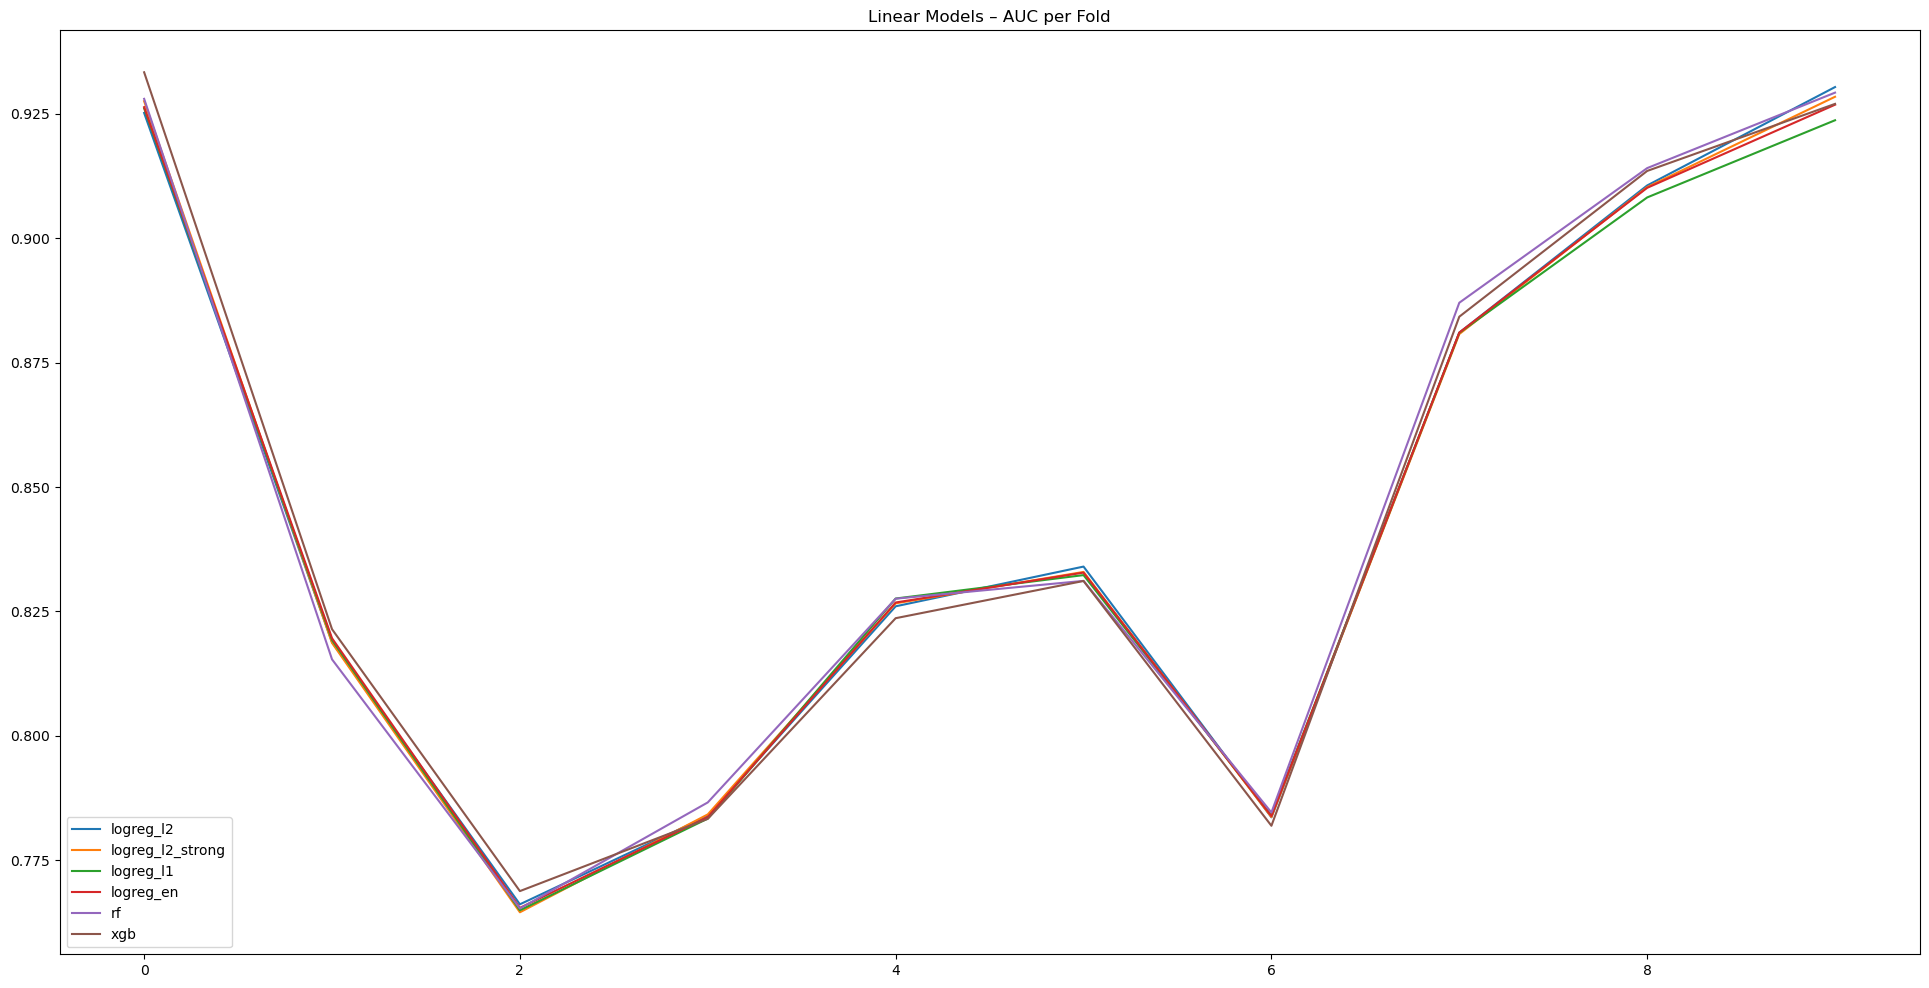

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(24, 12))

for k, v in all_results.items():
    plt.plot(v["fold_aucs"], label=k)

plt.legend()
plt.title("Linear Models – AUC per Fold")
plt.show()

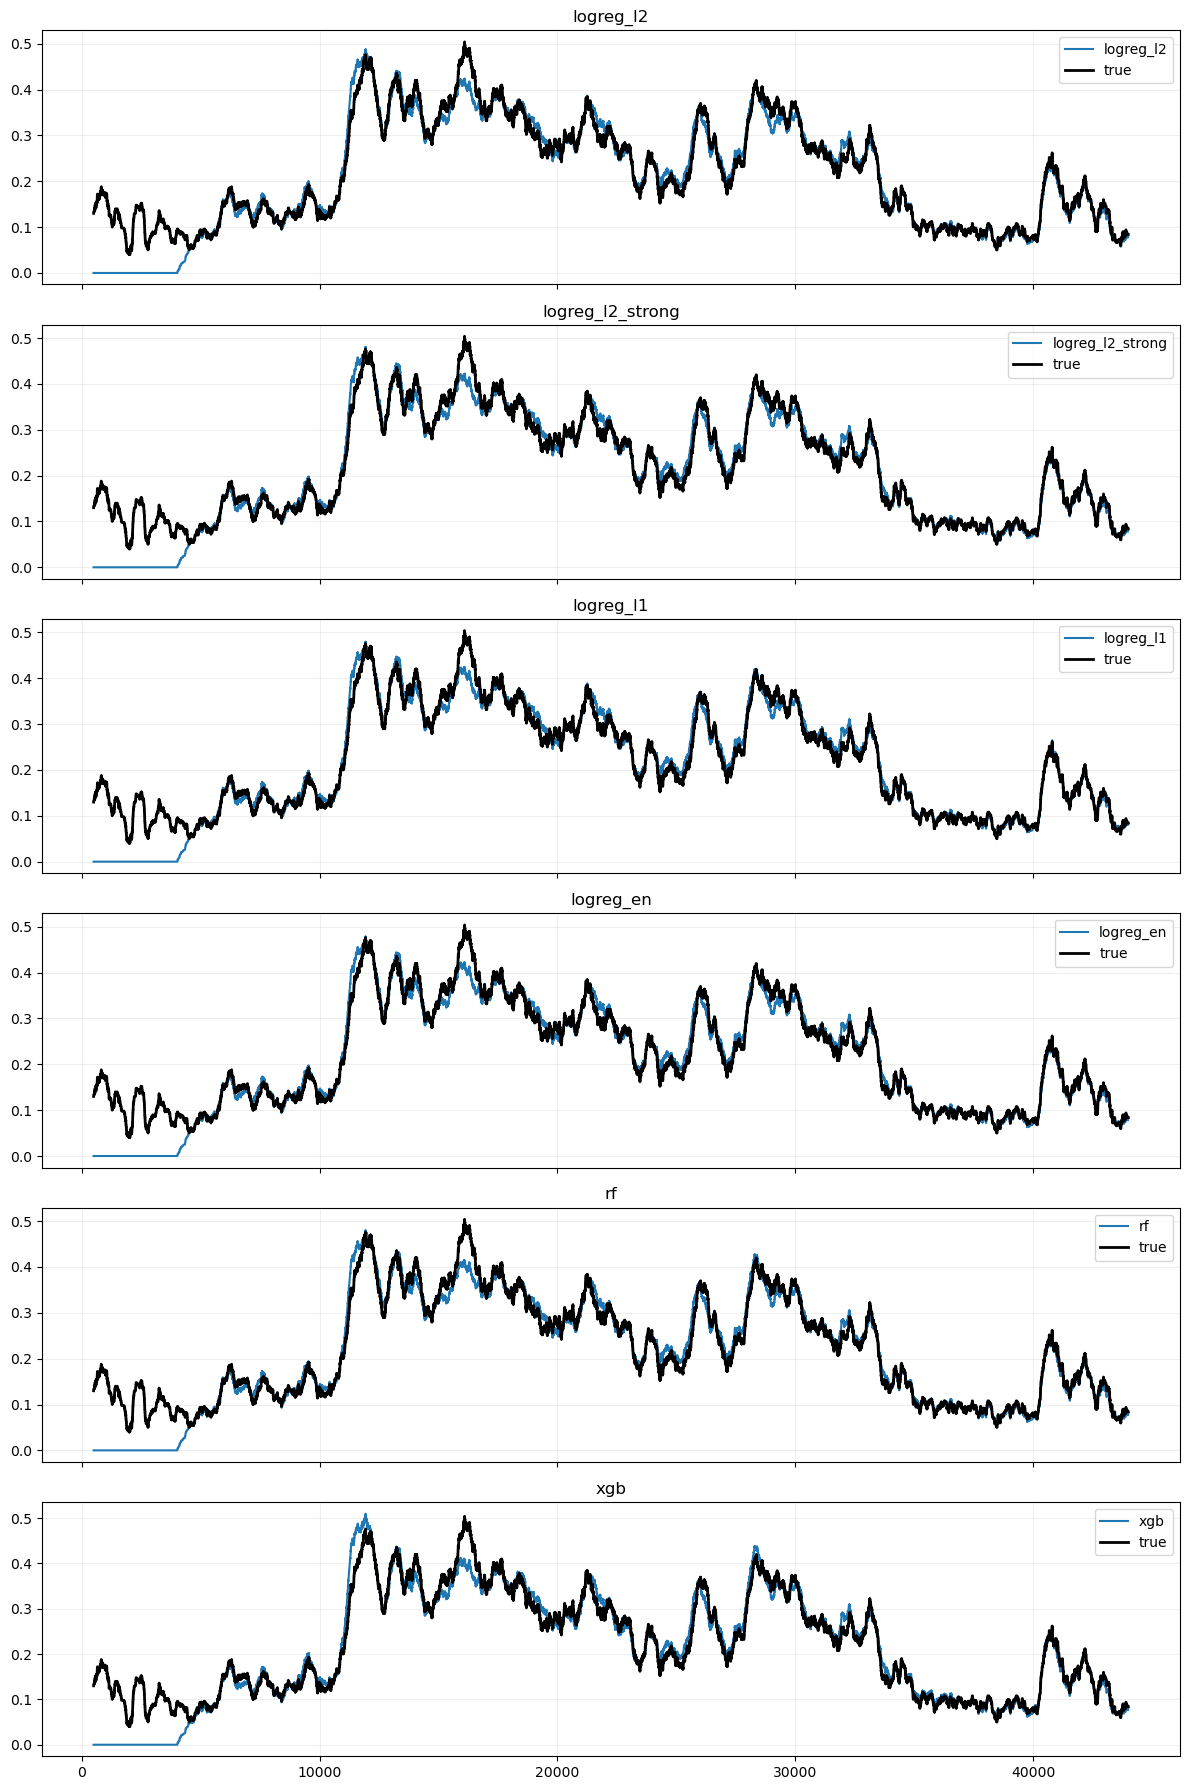

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

window = 500
y_true = y.values
target_smooth = pd.Series(y_true).rolling(window).mean()

n_models = len(all_results)
fig, axes = plt.subplots(n_models, 1, figsize=(12, 3 * n_models), sharex=True)

# if only 1 model, make axes iterable
if n_models == 1:
    axes = [axes]

for ax, (k, v) in zip(axes, all_results.items()):

    preds = np.nansum(v["fold_oof"], axis=0)

    pred_smooth = pd.Series(preds).rolling(window).mean()

    ax.plot(pred_smooth, label=k)
    ax.plot(target_smooth, color="black", linewidth=2, label="true")

    ax.set_title(k)
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

all_importance = {}

for name, res in all_results.items():
    coef_df = pd.DataFrame(res["coefs"], columns=X.columns)
    avg = coef_df.mean()
    all_importance[name] = avg

importance_df = pd.DataFrame(all_importance)

In [20]:
top_n = 130
pd.set_option('display.max_rows', 500)
cols = {}

for model in importance_df.columns:
    sorted_feats = (
        importance_df[model]
        .sort_values(key=abs, ascending=False)
        .head(top_n)
    )
    cols[model] = sorted_feats.reset_index(drop=False)

# combine side-by-side
out = pd.concat(cols, axis=1)

out

logreg_l2                       logreg_l2_strong  \
                          index logreg_l2                        index   
0                   imbalance_1  1.080820                  imbalance_1   
1        trade_volume_imbalance  0.720606       trade_volume_imbalance   
2                   imbalance_5  0.664607                  imbalance_5   
3             sell_volume_log1p -0.266957    total_bid_volume_10_log1p   
4   max_bid_ask_vol_ratio_log1p  0.132737  max_bid_ask_vol_ratio_log1p   
5     total_ask_volume_10_log1p  0.111673            sell_volume_log1p   
6             lob_depth_ratio_3  0.026128    total_ask_volume_10_log1p   
7         mid_minus_micro_log1p -0.005307            lob_depth_ratio_3   
8                  log_return_2 -0.001687        mid_minus_micro_log1p   
9         realized_vol_20_log1p  0.000687                 log_return_2   
10    total_bid_volume_10_log1p -0.000498        realized_vol_20_log1p   

                                       logreg_l1            \
   logreg_l2_strong                        index logreg_l1   
0          0.688789                  imbalance_1  0.995510   
1          0.647922       trade_volume_imbalance  0.633435   
2          0.573695                  imbalance_5  0.442075   
3          0.181108    total_ask_volume_10_log1p -0.134798   
4          0.175684  max_bid_ask_vol_ratio_log1p  0.112627   
5         -0.156917            lob_depth_ratio_3  0.031860   
6         -0.108648            sell_volume_log1p -0.022030   
7          0.031134    total_bid_volume_10_log1p  0.001199   
8         -0.003449        mid_minus_micro_log1p  0.000000   
9         -0.000330                 log_return_2  0.000000   
10         0.000224        realized_vol_20_log1p  0.000000   

                      logreg_en                                     rf  \
                          index logreg_en                        index   
0                   imbalance_1  0.763757  max_bid_ask_vol_ratio_log1p   
1        trade_volume_imbalance  0.642674        mid_minus_micro_log1p   
2                   imbalance_5  0.559431                  imbalance_5   
3   max_bid_ask_vol_ratio_log1p  0.175967    total_ask_volume_10_log1p   
4     total_bid_volume_10_log1p  0.110499                  imbalance_1   
5             sell_volume_log1p -0.067712    total_bid_volume_10_log1p   
6     total_ask_volume_10_log1p -0.053077            lob_depth_ratio_3   
7             lob_depth_ratio_3  0.032520       trade_volume_imbalance   
8         mid_minus_micro_log1p  0.000000                 log_return_2   
9                  log_return_2  0.000000            sell_volume_log1p   
10        realized_vol_20_log1p  0.000000        realized_vol_20_log1p   

                                      xgb             
          rf                        index        xgb  
0   0.176090  max_bid_ask_vol_ratio_log1p  17.879306  
1   0.175286                  imbalance_1  12.891942  
2   0.147749        mid_minus_micro_log1p  10.146030  
3   0.137719                  imbalance_5  10.081726  
4   0.126055    total_ask_volume_10_log1p   9.170995  
5   0.115945    total_bid_volume_10_log1p   5.273293  
6   0.041495       trade_volume_imbalance   4.912869  
7   0.034944            sell_volume_log1p   3.447241  
8   0.016193        realized_vol_20_log1p   3.194831  
9   0.015309                 log_return_2   3.072786  
10  0.013215            lob_depth_ratio_3   2.903305

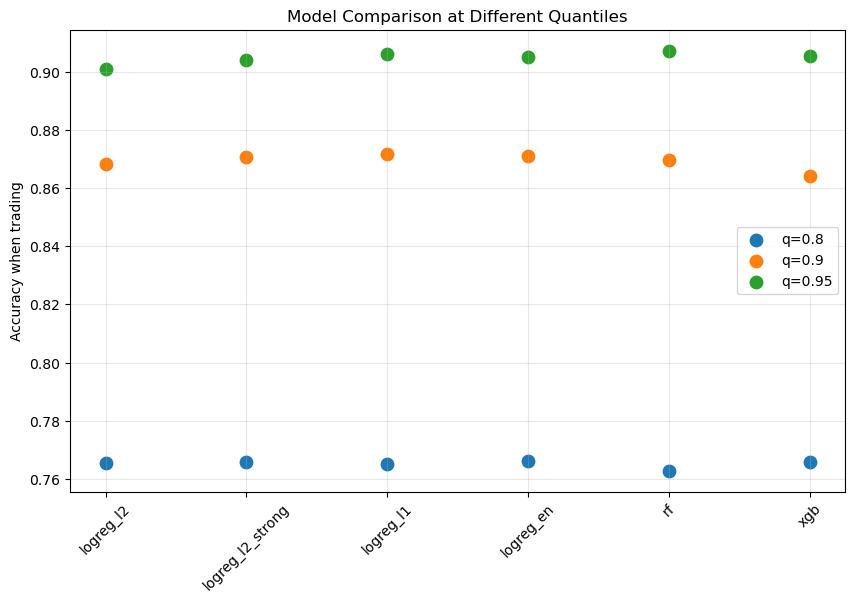

In [21]:
import matplotlib.pyplot as plt
import numpy as np

quantiles = [0.8, 0.9, 0.95]

model_names = list(all_results.keys())
x = np.arange(len(model_names))

plt.figure(figsize=(10, 6))

for q in quantiles:

    accs = []

    for name in model_names:

        preds = np.nansum(all_results[name]["fold_oof"], axis=0)

        threshold = np.quantile(preds, q)
        signal = preds > threshold

        acc = y_true[signal].mean()
        accs.append(acc)

    plt.scatter(x, accs, label=f"q={q}", s=80)

# formatting
plt.xticks(x, model_names, rotation=45)
plt.ylabel("Accuracy when trading")
plt.title("Model Comparison at Different Quantiles")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# final set of features and model

In [22]:
features = [
    "imbalance_5",
    "imbalance_1",
    "trade_volume_imbalance",
    "mid_minus_micro_log1p",
    "max_bid_ask_vol_ratio_log1p",
    "sell_volume_log1p",
    "lob_depth_ratio_3",
    "realized_vol_20_log1p",
    "log_return_2",
    "total_ask_volume_10_log1p",
    "total_bid_volume_10_log1p",
]
xgb= XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=1.0,
    n_jobs=1,
    random_state=42,
    eval_metric="logloss"
)